In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf





In [2]:
df = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
df = df.reset_index()
print(df.head())
print(df.isnull().sum())
print(df.columns.tolist())


C:\Users\user\AppData\Local\Temp\ipykernel_35372\1473964036.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2015-01-02  24.214895  24.682228  23.776355  24.671153  212818400
1      2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000
2      2015-01-06  23.534937  23.794073  23.173916  23.596952  263188400
3      2015-01-07  23.864941  23.964608  23.632381  23.743124  160423600
4      2015-01-08  24.781893  24.839479  24.075357  24.192745  237458000
Price   Ticker
Date              0
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
[('Date', ''), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


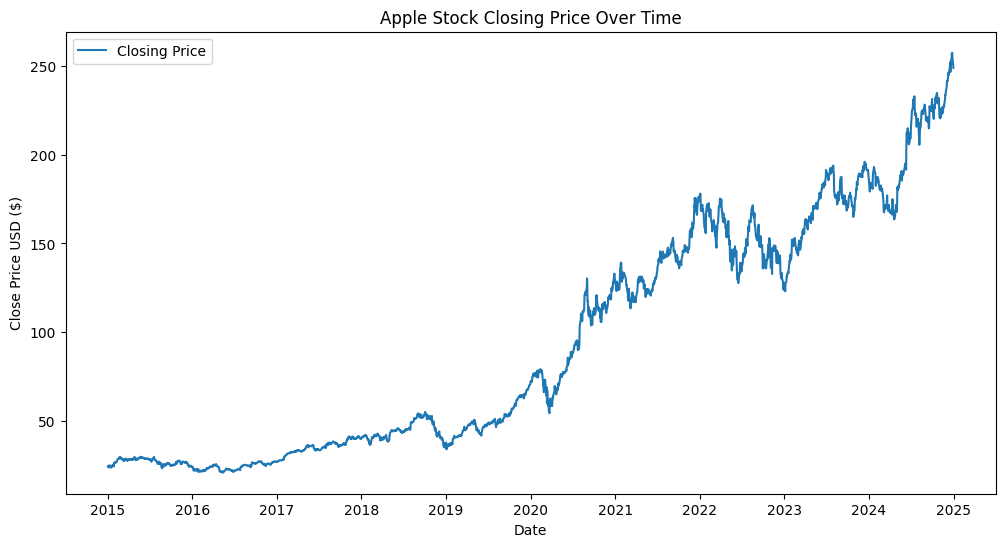

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label="Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price USD ($)")
plt.title("Apple Stock Closing Price Over Time")
plt.legend()
plt.show()

In [4]:
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Lag1_Close'] = df['Close'].shift(1)
print(df.head(10))

Price        Date      Close       High        Low       Open     Volume  \
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL   
0      2015-01-02  24.214895  24.682228  23.776355  24.671153  212818400   
1      2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000   
2      2015-01-06  23.534937  23.794073  23.173916  23.596952  263188400   
3      2015-01-07  23.864941  23.964608  23.632381  23.743124  160423600   
4      2015-01-08  24.781893  24.839479  24.075357  24.192745  237458000   
5      2015-01-09  24.808464  25.083104  24.409792  24.954643  214798000   
6      2015-01-12  24.197176  24.945793  24.097509  24.939149  198603200   
7      2015-01-13  24.412012  24.983442  24.121868  24.680008  268367600   
8      2015-01-14  24.318996  24.471820  24.031066  24.150668  195826400   
9      2015-01-15  23.658962  24.376571  23.623526  24.363283  240056000   

Price         MA7 MA30 Daily_Return Lag1_Close  
Ticker                                

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [6]:
df_reg = df.dropna()

# Features & target
X = df_reg[['Open','High','Low','Volume','MA7','MA30','Daily_Return','Lag1_Close']]
y = df_reg['Close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# 3. XGBoost Regressor
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

# Evaluation
models = {"Linear Regression": pred_lr, "Random Forest": pred_rf, "XGBoost": pred_xgb}
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name} - RMSE: {rmse:.4f}, R2: {r2:.4f}")
    
# --- Predict NEXT DAY close price ---
latest_data = df_reg.iloc[-1]   # last row in dataset
latest_features =np.array([
    latest_data['Open'],
    latest_data['High'],
    latest_data['Low'],
    latest_data['Volume'],
    latest_data['MA7'],
    latest_data['MA30'],
    latest_data['Daily_Return'],
    latest_data['Lag1_Close']
   ])
latest_features = latest_features.reshape(1, 8)# one sample,8 features
print(latest_features.shape)


next_day_pred1 = lr.predict(latest_features)
next_day_pred2 = rf.predict(latest_features)
next_day_pred3 = xgb.predict(latest_features)
print("Predicted next day closing price by linear:", next_day_pred1[0])
print("Predicted next day closing price by RandomForestRegressor:", next_day_pred2[0])
print("Predicted next day closing price by xgb:", next_day_pred3[0])


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Linear Regression - RMSE: 0.5807, R2: 0.9999
Random Forest - RMSE: 0.7950, R2: 0.9998
XGBoost - RMSE: 1.0929, R2: 0.9997
(1, 8)
Predicted next day closing price by linear: [249.67820548]
Predicted next day closing price by RandomForestRegressor: 249.8882305908203
Predicted next day closing price by xgb: 249.12451


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create target variable
df_cls = df.dropna().copy()
df_cls['Target'] = np.where(df_cls['Close'].shift(-1) > df_cls['Close'], 1, 0)

# Features & target
X_cls = df_cls[['Open','High','Low','Volume','MA7','MA30','Daily_Return','Lag1_Close']]
y_cls = df_cls['Target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cls)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls, test_size=0.2, shuffle=False)

# 1. Logistic Regression
logreg = LogisticRegression(max_iter=1000,solver='saga')
logreg.fit(X_train_cls, y_train_cls)
pred_log = logreg.predict(X_test_cls)

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_cls, y_train_cls)
pred_dt = dt.predict(X_test_cls)

# 3. SVM
svm = SVC()
svm.fit(X_train_cls, y_train_cls)
pred_svm = svm.predict(X_test_cls)

# Evaluation
models_cls = {"Logistic Regression": pred_log, "Decision Tree": pred_dt, "SVM": pred_svm}
for name, pred in models_cls.items():
    acc = accuracy_score(y_test_cls, pred)
    prec = precision_score(y_test_cls, pred)
    rec = recall_score(y_test_cls, pred)
    f1 = f1_score(y_test_cls, pred)
    print(f"{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

 # --- Predict NEXT DAY direction ---
latest_data_cls = df_cls.iloc[-1]  # last row of the dataframe

# Prepare features in the same order as training
latest_features_cls = np.array([
    latest_data_cls['Open'],
    latest_data_cls['High'],
    latest_data_cls['Low'],
    latest_data_cls['Volume'],
    latest_data_cls['MA7'],
    latest_data_cls['MA30'],
    latest_data_cls['Daily_Return'],
    latest_data_cls['Lag1_Close']
], dtype=float).reshape(1, -1)  # shape (1, 8)

# Predictions
pred_next_logreg = logreg.predict(latest_features_cls)[0]
pred_next_dt = dt.predict(latest_features_cls)[0]
pred_next_svm = svm.predict(latest_features_cls)[0]

# Print results
def direction_label(val):
    return "Up" if val == 1 else "Down"

print("Goal: Predict whether stock will go UP (1) or DOWN (0) tomorrow.")
print(f"Logistic Regression predicts: {direction_label(pred_next_logreg)}")
print(f"Decision Tree predicts: {direction_label(pred_next_dt)}")
print(f"SVM predicts: {direction_label(pred_next_svm)}")
   


Logistic Regression - Accuracy: 0.4980, Precision: 0.5607, Recall: 0.4803, F1: 0.5174
Decision Tree - Accuracy: 0.4699, Precision: 0.5701, Recall: 0.2186, F1: 0.3161
SVM - Accuracy: 0.4598, Precision: 0.6250, Recall: 0.0896, F1: 0.1567
Goal: Predict whether stock will go UP (1) or DOWN (0) tomorrow.
Logistic Regression predicts: Down
Decision Tree predicts: Down
SVM predicts: Up


In [10]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Normalize features
scaler_x = MinMaxScaler()
scaler_y= MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

# Build ANN
ann = Sequential()
ann.add(Dense(100, activation='relu', input_shape=(X_train_dl.shape[1],)))
ann.add(Dense(25, activation='relu'))
ann.add(Dense(1, activation='linear'))

ann.compile(optimizer='adam', loss='mse')
history = ann.fit(X_train_dl, y_train_dl, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Evaluate
pred_ann = ann.predict(X_test_dl)
rmse_ann = np.sqrt(mean_squared_error(y_test_dl, pred_ann))
print("ANN RMSE:", rmse_ann)
# --- Predict Next Day's Closing Price ---

# Get the last row of features from X (already scaled)
last_features = X_scaled[-1].reshape(1, -1)

# Predict next day scaled price
next_day_scaled = ann.predict(last_features)[0][0]

# Inverse transform to get the actual price
next_day_price = scaler_y.inverse_transform([[next_day_scaled]])[0][0]

print(f"Goal: Predict the NEXT DAY closing price")
print(f"Predicted Next Day Closing Price: {next_day_price:.2f}")


Epoch 1/20


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0083 - val_loss: 5.7089e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3725e-04 - val_loss: 3.1279e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4634e-05 - val_loss: 2.7091e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1468e-05 - val_loss: 2.5034e-04
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9222e-05 - val_loss: 2.3555e-04
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0972e-05 - val_loss: 2.2018e-04
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5750e-05 - val_loss: 1.6977e-04
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2477e-05 - val_loss: 1.5301e-04
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7356e-05 - val_loss: 1.4072e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3516e-05 - val_loss: 1.2189e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2566e-05 - val_loss: 1.1000e-04
E

Epoch 1/20


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0084
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0013
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0010    
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 9.0457e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.6088e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.6830e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.6209e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 8.4873e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7.2785e-04
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7.4646e-04
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7.1463e-04
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 6.7803e-04
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 6.5809e-04
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━━

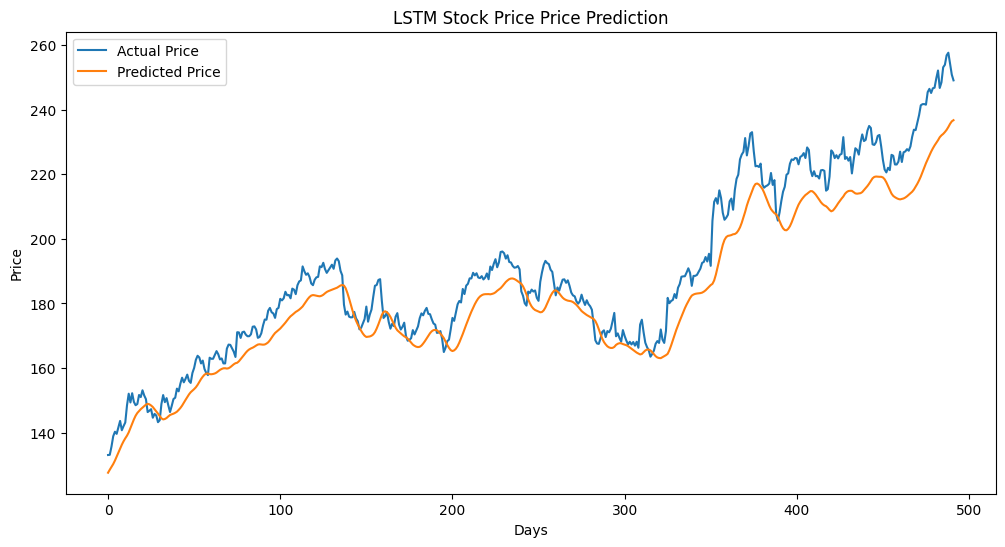

In [11]:
from tensorflow.keras.layers import LSTM, Dropout

# Use only closing prices for LSTM
data = df[['Close']].values

# Scale data
scaler_lstm = MinMaxScaler()
data_scaled = scaler_lstm.fit_transform(data)

# Create sequences of 60 days
X_lstm, y_lstm = [], []
for i in range(60, len(data_scaled)):
    X_lstm.append(data_scaled[i-60:i, 0])
    y_lstm.append(data_scaled[i, 0])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Reshape for LSTM (samples, timesteps, features)
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

# Train-test split
split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

# Build LSTM model
lstm = Sequential()
lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
lstm.add(Dropout(0.2))
lstm.add(LSTM(50, return_sequences=False))
lstm.add(Dropout(0.2))
lstm.add(Dense(1))

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=1)

# Predictions
pred_lstm = lstm.predict(X_test_lstm)
pred_lstm = scaler_lstm.inverse_transform(pred_lstm.reshape(-1,1))
y_test_lstm_rescaled = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1,1))

# Plot predicted vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test_lstm_rescaled, label="Actual Price")
plt.plot(pred_lstm, label="Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.title("LSTM Stock Price Price Prediction")
plt.legend()
plt.show()